In [2]:
# FASE 2: ANÁLISIS CON PYTHON
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Conectar a la base de datos SQL
conn = sqlite3.connect(r'C:\Users\Lenovo\Documents\ProjectAnalyticsChampions\champions_league_2025.db')

# Cargar datos
df = pd.read_sql_query("SELECT * FROM champions_league_matches", conn)

# Ver primeras filas
print("Shape:", df.shape)
print("\nColumnas:", df.columns.tolist())
df.head()

Shape: (151, 18)

Columnas: ['date', 'home_team', 'away_team', 'score', 'venue', 'referee', 'home_possession', 'away_possession', 'home_shots_on_target', 'away_shots_on_target', 'home_saves', 'away_saves', 'home_shots_on_target_pct', 'away_shots_on_target_pct', 'home_saves_pct', 'away_saves_pct', 'result', 'winner']


,date,home_team,away_team,score,venue,referee,home_possession,away_possession,home_shots_on_target,away_shots_on_target,home_saves,away_saves,home_shots_on_target_pct,away_shots_on_target_pct,home_saves_pct,away_saves_pct,result,winner
0,2025-09-16,PSV,Union SG,1–3,Philips Stadion,Anthony Taylor,63%,37%,3 of 10,8 of 18,4 of 8,2 of 3,30.0,44.4,50.0,66.7,Away Win,Union SG
1,2025-09-16,Athletic Club,Arsenal,0–2,San Mamés,Donatas Rumšas,38%,62%,2 of 11,6 of 11,4 of 6,2 of 2,18.2,54.5,66.7,100.0,Away Win,Arsenal
2,2025-09-16,Tottenham Hotspur,Villarreal,1–0,Tottenham Hotspur Stadium,Rade Obrenović,58%,42%,1 of 9,0 of 10,0 of 0,1 of 1,11.1,0.0,None,100.0,Home Win,Tottenham Hotspur
3,2025-09-16,Benfica,Qarabağ,2–3,Estádio do Sport Lisboa e Benfica,Erik Lambrechts,53%,47%,3 of 14,5 of 10,2 of 5,1 of 3,21.4,50.0,40.0,33.3,Away Win,Qarabağ
4,2025-09-16,Juventus,Dortmund,4–4,Allianz Stadium,François Letexier,52%,48%,7 of 19,5 of 10,1 of 5,3 of 7,36.8,50.0,20.0,42.9,Draw,Draw


In [6]:
# Verificar qué separador usa el score
print(df['score'].head(10))
print("\nValores nulos en score:", df['score'].isna().sum())

# Limpiar filas con score nulo
df = df.dropna(subset=['score'])

# Detectar separador automáticamente
df['home_goals'] = df['score'].str.extract(r'(\d+)').astype(int)
df['away_goals'] = df['score'].str.extract(r'\d+[^\d]+(\d+)').astype(int)
df['total_goals'] = df['home_goals'] + df['away_goals']

# Convertir fecha
df['date'] = pd.to_datetime(df['date'])

print("\nDatos limpios! Shape:", df.shape)
print(df[['date','home_team','away_team','home_goals','away_goals','total_goals']].head())

0    1–3
1    0–2
2    1–0
3    2–3
4    4–4
5    2–1
6    2–2
7    0–0
8    3–2
9    0–2
Name: score, dtype: object

Valores nulos en score: 7

Datos limpios! Shape: (144, 21)
        date          home_team   away_team  home_goals  away_goals  \
0 2025-09-16                PSV    Union SG           1           3   
1 2025-09-16      Athletic Club     Arsenal           0           2   
2 2025-09-16  Tottenham Hotspur  Villarreal           1           0   
3 2025-09-16            Benfica     Qarabağ           2           3   
4 2025-09-16           Juventus    Dortmund           4           4   

   total_goals  
0            4  
1            2  
2            1  
3            5  
4            8  


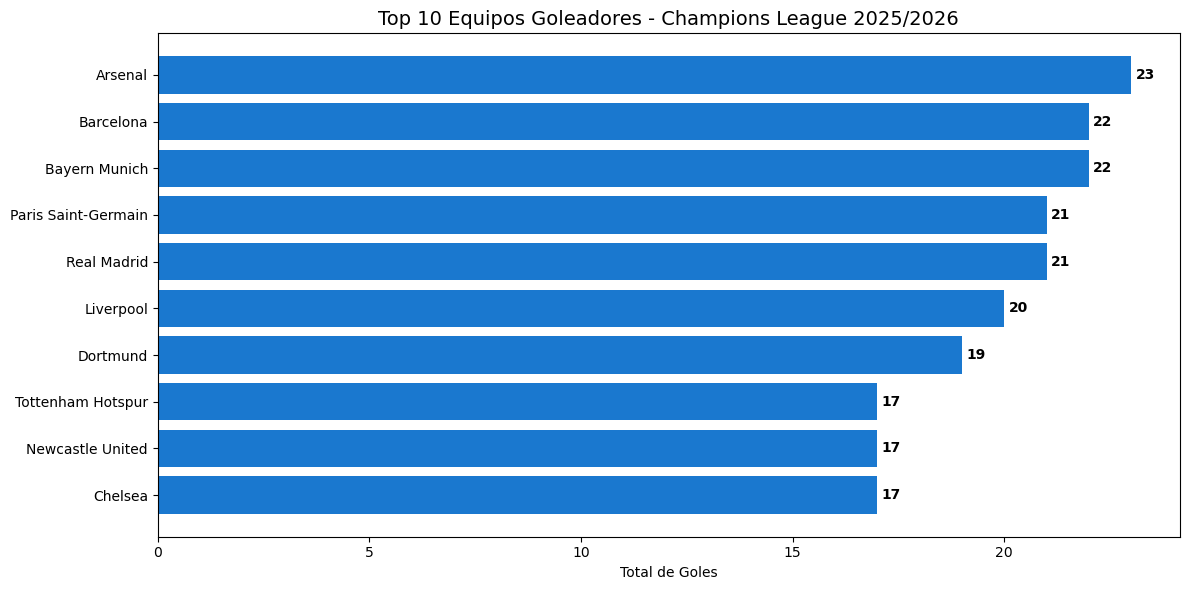

In [7]:
# GRÁFICO 1: Top 10 equipos con más goles
goles_local = df.groupby('home_team')['home_goals'].sum()
goles_visita = df.groupby('away_team')['away_goals'].sum()
total_goles = (goles_local.add(goles_visita, fill_value=0)
               .sort_values(ascending=False).head(10))

plt.figure(figsize=(12,6))
bars = plt.barh(total_goles.index, total_goles.values, color='#1a78cf')
plt.xlabel('Total de Goles')
plt.title('Top 10 Equipos Goleadores - Champions League 2025/2026', fontsize=14)
plt.gca().invert_yaxis()
for bar, val in zip(bars, total_goles.values):
    plt.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2, 
             str(int(val)), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('top10_goleadores.png', dpi=150)
plt.show()

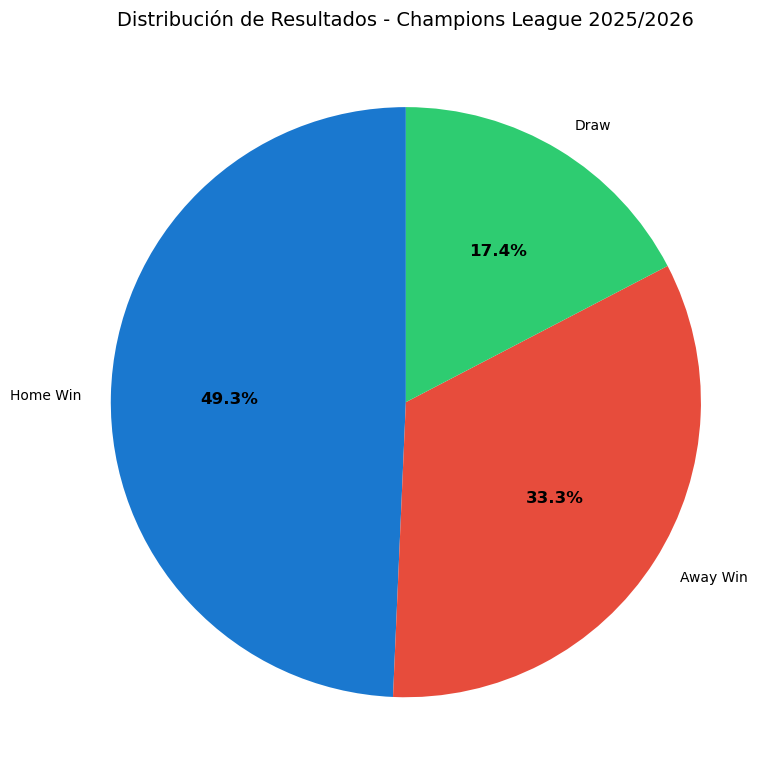

In [8]:
# GRÁFICO 2: Distribución de resultados
resultado_count = df['result'].value_counts()

plt.figure(figsize=(8,8))
colors = ['#1a78cf', '#e74c3c', '#2ecc71']
wedges, texts, autotexts = plt.pie(resultado_count.values, 
                                    labels=resultado_count.index,
                                    autopct='%1.1f%%',
                                    colors=colors,
                                    startangle=90)
for text in autotexts:
    text.set_fontweight('bold')
    text.set_fontsize(12)
plt.title('Distribución de Resultados - Champions League 2025/2026', fontsize=14)
plt.tight_layout()
plt.savefig('distribucion_resultados.png', dpi=150)
plt.show()

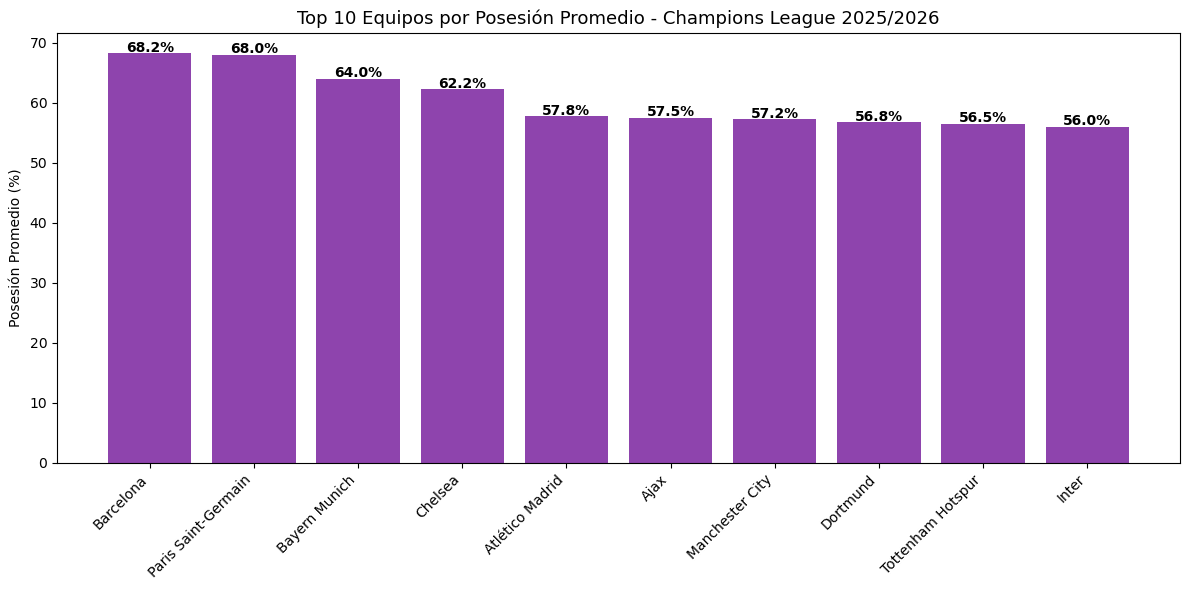

In [9]:
# GRÁFICO 3: Posesión promedio por equipo
posesion = df.groupby('home_team')['home_possession'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
bars = plt.bar(posesion.index, posesion.values, color='#8e44ad')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Posesión Promedio (%)')
plt.title('Top 10 Equipos por Posesión Promedio - Champions League 2025/2026', fontsize=13)
for bar, val in zip(bars, posesion.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('posesion_promedio.png', dpi=150)
plt.show()

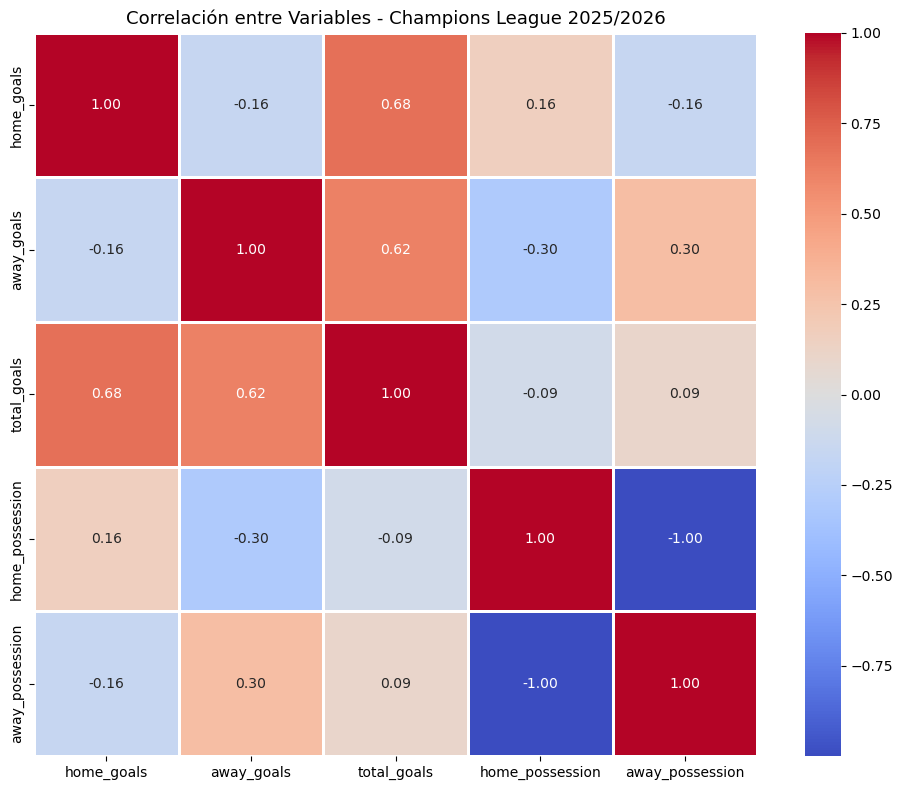

In [10]:
# GRÁFICO 4: Heatmap de correlaciones
plt.figure(figsize=(10,8))
cols = ['home_goals','away_goals','total_goals','home_possession','away_possession']
correlacion = df[cols].corr()

sns.heatmap(correlacion, 
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=1)
plt.title('Correlación entre Variables - Champions League 2025/2026', fontsize=13)
plt.tight_layout()
plt.savefig('heatmap_correlacion.png', dpi=150)
plt.show()

In [11]:
# Exportar datos limpios para Excel y Power BI
df.to_csv('champions_league_limpio.csv', index=False)
df.to_excel('champions_league_limpio.xlsx', index=False)

print("✅ Archivos exportados:")
print("   - champions_league_limpio.csv")
print("   - champions_league_limpio.xlsx")
print(f"\nTotal partidos: {len(df)}")
print(f"Total goles: {df['total_goals'].sum()}")
print(f"Promedio goles por partido: {df['total_goals'].mean():.2f}")
print(f"Partido más goleador: {df.loc[df['total_goals'].idxmax(), 'home_team']} vs {df.loc[df['total_goals'].idxmax(), 'away_team']} ({df['total_goals'].max()} goles)")

✅ Archivos exportados:
   - champions_league_limpio.csv
   - champions_league_limpio.xlsx

Total partidos: 144
Total goles: 487
Promedio goles por partido: 3.38
Partido más goleador: Leverkusen vs Paris Saint-Germain (9 goles)
